# 07 — FFT segmentada (método de Welch) como entrada de frequência

**Estratégia proposta** (formalizada, é o estimador espectral de Welch):

1. a janela de 168 h é dividida em **K = 6 segmentos** de 48 h;
2. os segmentos se **sobrepõem** em 50 % (passo de 24 h);
3. cada segmento passa por uma **rFFT**;
4. as componentes de **mesmo período** são promediadas entre os segmentos;
5. as médias de [log1p(amplitude), Re, Im] são **concatenadas** → 75 dims de
   frequência (vs 255 da FFT única da janela inteira).

**Hipóteses.** (i) A média entre segmentos reduz a variância do estimador espectral
(propriedade clássica do método de Welch); (ii) um bloco mascarado corrompe apenas os
segmentos que o contêm e a média pode diluir esse efeito, enquanto na FFT única o
vazamento espectral da lacuna contamina todos os bins; (iii) a grade de frequências
mais grossa concentra-se nos períodos ≤ 48 h — o ciclo diário cai num bin exato — e
entrega 3× menos dimensões (menos ruído) à projeção do token [FREQ]. O notebook 04
mostrou que a FFT única não agrega sobre a ablação; a questão aqui é se o estimador
segmentado muda esse quadro.

**Desenho experimental: fatorial 3 × 2** — {sem FFT, FFT padrão, FFT segmentada} ×
{BERT, SAITS} — 6 modelos, TODOS retreinados do zero com o novo orçamento:
**300 épocas, early stopping com paciência 30**, semente 42, mesmos dados e máscaras
de treino. Família BERT: atenção completa + token [MASK] + perda MIT (notebook 02).
Família SAITS: DMSA + perda MIT+ORT, 1 passada (notebook 04). Avaliação no protocolo
fixo (máscaras semente 123, 6 cenários, baselines). O laço de treino é idempotente
(marcador = `historico.json`; seguro reexecutar).

**Artefatos**: `resultados/fft_segmentada/{modelo}/`, `resultados/metricas_fft_seg.{csv,json}`
e `resultados/comparacao_fft_seg.csv`; nada anterior é sobrescrito. Como o orçamento de
treino mudou, estes números **não** são comparáveis aos dos notebooks 03–06 (40 épocas).

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd()))
from src import dados
from src.estilo import aplicar_estilo, PALETA, TINTA_2
from src.modelo import BERTImputador
from src.saits_fft import (SAITSFFT, BERTFFT, carregar_saits, carregar_bert_fft,
                           comprimento_segmento)
from src.treino import (treinar, fixar_semente, carregar_modelo,
                        perda_mascarada, perda_mit_ort)
from src.avaliacao import avaliar_metodos

aplicar_estilo()

device = "cuda" if torch.cuda.is_available() else "cpu"
arrays, stats, cfg_dados = dados.carregar_processado("dados_processados")
ds_treino = dados.JanelasDataset(arrays["treino"])
ds_val = dados.JanelasDataset(arrays["val"])
print(f"device: {device}  |  janelas de treino: {len(ds_treino):,}  |  validação: {len(ds_val):,}")

device: cuda  |  janelas de treino: 72,500  |  validação: 2,500


In [2]:
CFG = {
    "semente": 42,
    "epocas": 300,
    "batch": 256,
    "lr": 1e-3,
    "paciencia": 30,          # critério de parada pedido p/ este experimento
    "mascara": {"razao": 0.25, "prob_bloco": 0.5, "lm": 6.0},
}
BASE = dict(seq_len=168, d_model=64, n_camadas=3, n_cabecas=4, d_ff=256, dropout=0.1)
N_SEG = 6
print(f"segmentos: {N_SEG} × {comprimento_segmento(168, N_SEG)}h (passo 24h)")

ESPECS = {
    "BERT": dict(tipo="bert", pasta="bert", fn_perda=perda_mascarada),
    "BERT+FFT (padrão)": dict(tipo="bertfft", pasta="bert_fftp", fn_perda=perda_mascarada,
                              extra=dict(modo_fft="padrao")),
    "BERT+FFT (segmentada)": dict(tipo="bertfft", pasta="bert_ffts", fn_perda=perda_mascarada,
                                  extra=dict(modo_fft="segmentada", n_segmentos=N_SEG)),
    "SAITS (DMSA+ORT)": dict(tipo="saits", pasta="saits", fn_perda=perda_mit_ort,
                             extra=dict(usar_fft=False)),
    "SAITS-FFT (padrão)": dict(tipo="saits", pasta="saits_fftp", fn_perda=perda_mit_ort,
                               extra=dict(usar_fft=True, modo_fft="padrao")),
    "SAITS-FFT (segmentada)": dict(tipo="saits", pasta="saits_ffts", fn_perda=perda_mit_ort,
                                   extra=dict(usar_fft=True, modo_fft="segmentada",
                                              n_segmentos=N_SEG)),
}

def construir(spec):
    if spec["tipo"] == "bert":
        return BERTImputador(**{k: BASE[k] for k in
                                ("d_model", "n_camadas", "n_cabecas", "d_ff", "dropout")})
    if spec["tipo"] == "bertfft":
        return BERTFFT(**BASE, **spec["extra"])
    return SAITSFFT(**BASE, **spec["extra"])

for nome, spec in ESPECS.items():
    n = sum(p.numel() for p in construir(spec).parameters())
    print(f"{nome:24s} {n:,} parâmetros")

segmentos: 6 × 48h (passo 24h)
BERT                     150,401 parâmetros
BERT+FFT (padrão)        170,945 parâmetros
BERT+FFT (segmentada)    159,425 parâmetros
SAITS (DMSA+ORT)         150,337 parâmetros
SAITS-FFT (padrão)       170,881 parâmetros
SAITS-FFT (segmentada)   159,361 parâmetros


C:\Users\celso\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [3]:
%%time
# treinos (idempotente: pula quem já tem historico.json)
for nome, spec in ESPECS.items():
    pasta = Path("resultados/fft_segmentada") / spec["pasta"]
    if (pasta / "historico.json").exists():
        print(f"[já treinado] {nome}")
        continue
    print(f"\n=== treinando: {nome} (máx. {CFG['epocas']} épocas, paciência {CFG['paciencia']}) ===")
    fixar_semente(CFG["semente"])
    modelo = construir(spec)
    treinar(modelo, ds_treino, ds_val, CFG, device, str(pasta),
            fn_perda=spec["fn_perda"])


=== treinando: BERT (máx. 300 épocas, paciência 30) ===


época   1 | treino 0.2900 | val 0.1133  <- melhor


época   2 | treino 0.1176 | val 0.0913  <- melhor


época   3 | treino 0.1020 | val 0.0810  <- melhor


época   4 | treino 0.0939 | val 0.0751  <- melhor


...

época 151 | treino 0.0534 | val 0.0494


época 152 | treino 0.0527 | val 0.0495


época 153 | treino 0.0537 | val 0.0492


época 154 | treino 0.0529 | val 0.0494


época 155 | treino 0.0535 | val 0.0497
early stopping (sem melhora há 30 épocas)
CPU times: total: 21h 27min 34s
Wall time: 21h 8min 49s


BERT                     épocas: 150 | melhor val: 0.0504 (época 120)
BERT+FFT (padrão)        épocas: 187 | melhor val: 0.0486 (época 157)
BERT+FFT (segmentada)    épocas: 198 | melhor val: 0.0488 (época 168)
SAITS (DMSA+ORT)         épocas: 251 | melhor val: 0.0494 (época 226)
SAITS-FFT (padrão)       épocas: 155 | melhor val: 0.0488 (época 125)
SAITS-FFT (segmentada)   épocas: 155 | melhor val: 0.0486 (época 125)


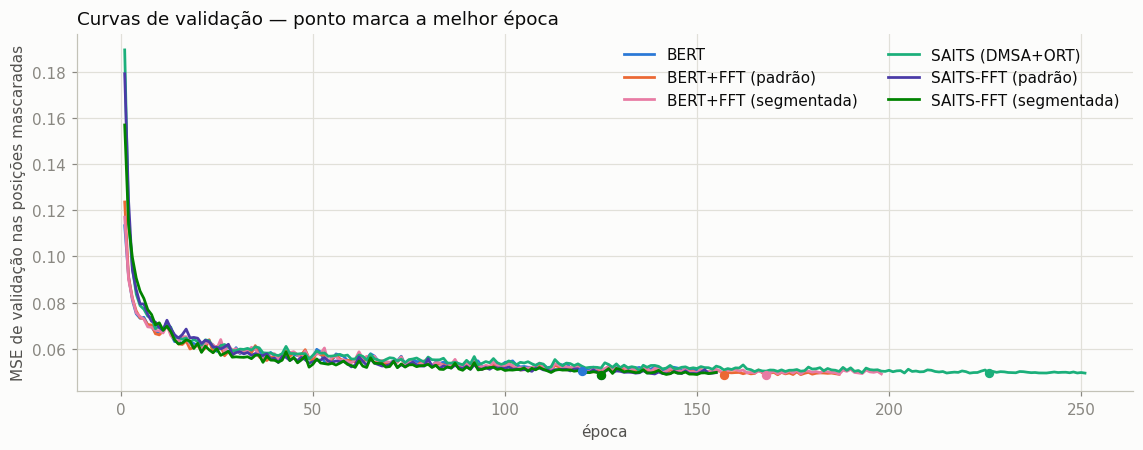

In [4]:
# curvas de validação (MSE nas posições mascaradas → comparáveis entre os 6)
CORES_MODELOS = {
    "BERT": PALETA["azul"],
    "BERT+FFT (padrão)": PALETA["laranja"],
    "BERT+FFT (segmentada)": PALETA["magenta"],
    "SAITS (DMSA+ORT)": PALETA["verde_agua"],
    "SAITS-FFT (padrão)": PALETA["violeta"],
    "SAITS-FFT (segmentada)": PALETA["verde"],
}
fig, eixo = plt.subplots(figsize=(10.5, 4.2))
for nome, spec in ESPECS.items():
    with open(Path("resultados/fft_segmentada") / spec["pasta"] / "historico.json",
              encoding="utf-8") as f:
        hist = json.load(f)
    val = [h["perda_val"] for h in hist]
    eixo.plot(range(1, len(val) + 1), val, color=CORES_MODELOS[nome], label=nome)
    melhor = int(np.argmin(val))
    eixo.scatter(melhor + 1, val[melhor], s=26, color=CORES_MODELOS[nome], zorder=3)
    print(f"{nome:24s} épocas: {len(val):3d} | melhor val: {min(val):.4f} (época {melhor + 1})")
eixo.set_xlabel("época")
eixo.set_ylabel("MSE de validação nas posições mascaradas")
eixo.set_title("Curvas de validação — ponto marca a melhor época", loc="left")
eixo.legend(ncols=2)
fig.tight_layout()
plt.show()

## Avaliação no conjunto de teste

Protocolo fixo (máscaras semente 123, 6 cenários, baselines). Todos os modelos abaixo
foram treinados com o MESMO orçamento novo (300 épocas / paciência 30), então a
comparação interna é justa — e não deve ser misturada com os números de 40 épocas dos
notebooks anteriores.

In [5]:
%%time
j_teste, id_teste = arrays["teste"], arrays["id_teste"]
desvios = stats["desvio"].to_numpy()[id_teste].astype("float32")
medias = stats["media"].to_numpy()[id_teste].astype("float32")

CARREGADORES = {"bert": carregar_modelo, "bertfft": carregar_bert_fft, "saits": carregar_saits}
modelos = {
    nome: CARREGADORES[spec["tipo"]](
        str(Path("resultados/fft_segmentada") / spec["pasta"] / "melhor_modelo.pt"), device)
    for nome, spec in ESPECS.items()
}

cenarios = [
    (f"{tipo} {int(razao*100)}%", tipo, razao)
    for tipo in ("pontual", "bloco")
    for razao in (0.10, 0.25, 0.50)
]
resultados = avaliar_metodos(
    j_teste, modelos, device, cenarios,
    semente=123, desvios=desvios, medias=medias,
)
resultados.to_csv("resultados/metricas_fft_seg.csv", index=False)
resultados.to_json("resultados/metricas_fft_seg.json", orient="records",
                   indent=2, force_ascii=False)
resultados.round(4)

CPU times: total: 1min 18s
Wall time: 46.2 s


,cenário,método,MAE,RMSE,MAE_kW,RMSE_kW,MRE
0,pontual 10%,BERT,0.1193,0.1966,13.0909,46.0737,0.0391
1,pontual 10%,BERT+FFT (padrão),0.1150,0.1910,12.3009,43.2959,0.0368
2,pontual 10%,BERT+FFT (segmentada),0.1153,0.1914,12.4100,44.6146,0.0371
3,pontual 10%,SAITS (DMSA+ORT),0.1147,0.1895,12.4381,43.6457,0.0372
4,pontual 10%,SAITS-FFT (padrão),0.1153,0.1899,12.3658,42.9505,0.0369
5,pontual 10%,SAITS-FFT (segmentada),0.1149,0.1898,12.3253,43.6735,0.0368
6,pontual 10%,média da janela,0.7789,0.9239,106.8868,308.9570,0.3194
7,pontual 10%,último valor (ffill),0.2929,0.4686,35.6964,145.3564,0.1067
8,pontual 10%,interpolação linear,0.1841,0.2884,21.5006,78.1609,0.0642
9,pontual 25%,BERT,0.1244,0.1977,13.3662,43.1870,0.0400


In [6]:
# MAE por cenário + deltas do desenho fatorial
nomes_cen = [c[0] for c in cenarios]
tabela_mae = resultados.pivot(index="cenário", columns="método", values="MAE").loc[nomes_cen]

pares = {
    "BERT+FFTp vs BERT": ("BERT+FFT (padrão)", "BERT"),
    "BERT+FFTs vs BERT": ("BERT+FFT (segmentada)", "BERT"),
    "BERT+FFTs vs BERT+FFTp": ("BERT+FFT (segmentada)", "BERT+FFT (padrão)"),
    "SAITS-FFTp vs SAITS": ("SAITS-FFT (padrão)", "SAITS (DMSA+ORT)"),
    "SAITS-FFTs vs SAITS": ("SAITS-FFT (segmentada)", "SAITS (DMSA+ORT)"),
    "SAITS-FFTs vs SAITS-FFTp": ("SAITS-FFT (segmentada)", "SAITS-FFT (padrão)"),
    "SAITS vs BERT": ("SAITS (DMSA+ORT)", "BERT"),
}
deltas = pd.DataFrame({
    rotulo: 100 * (tabela_mae[a] - tabela_mae[b]) / tabela_mae[b]
    for rotulo, (a, b) in pares.items()
}).loc[nomes_cen]

exib = tabela_mae[list(ESPECS)].copy()
exib.to_csv("resultados/comparacao_fft_seg.csv", encoding="utf-8-sig")
deltas.to_csv("resultados/deltas_fft_seg.csv", encoding="utf-8-sig")
print("salvos: resultados/comparacao_fft_seg.csv e resultados/deltas_fft_seg.csv")
exib.round(4)

salvos: resultados/comparacao_fft_seg.csv e resultados/deltas_fft_seg.csv


método,BERT,BERT+FFT (padrão),BERT+FFT (segmentada),SAITS (DMSA+ORT),SAITS-FFT (padrão),SAITS-FFT (segmentada)
cenário,,,,,,
pontual 10%,0.1193,0.1150,0.1153,0.1147,0.1153,0.1149
pontual 25%,0.1244,0.1209,0.1207,0.1206,0.1208,0.1208
pontual 50%,0.1428,0.1405,0.1392,0.1388,0.1396,0.1399
bloco 10%,0.1604,0.1559,0.1562,0.1575,0.1563,0.1567
bloco 25%,0.1628,0.1587,0.1589,0.1599,0.1590,0.1590
bloco 50%,0.1737,0.1709,0.1698,0.1709,0.1708,0.1711


In [7]:
deltas.round(2)  # negativo = primeira variante do par é melhor

,BERT+FFTp vs BERT,BERT+FFTs vs BERT,BERT+FFTs vs BERT+FFTp,SAITS-FFTp vs SAITS,SAITS-FFTs vs SAITS,SAITS-FFTs vs SAITS-FFTp,SAITS vs BERT
cenário,,,,,,,
pontual 10%,-3.59,-3.40,0.20,0.47,0.14,-0.34,-3.85
pontual 25%,-2.84,-2.97,-0.14,0.14,0.17,0.03,-3.04
pontual 50%,-1.64,-2.50,-0.87,0.57,0.76,0.20,-2.76
bloco 10%,-2.77,-2.57,0.21,-0.75,-0.53,0.23,-1.76
bloco 25%,-2.51,-2.39,0.13,-0.54,-0.54,0.00,-1.77
bloco 50%,-1.66,-2.25,-0.61,-0.05,0.15,0.20,-1.65


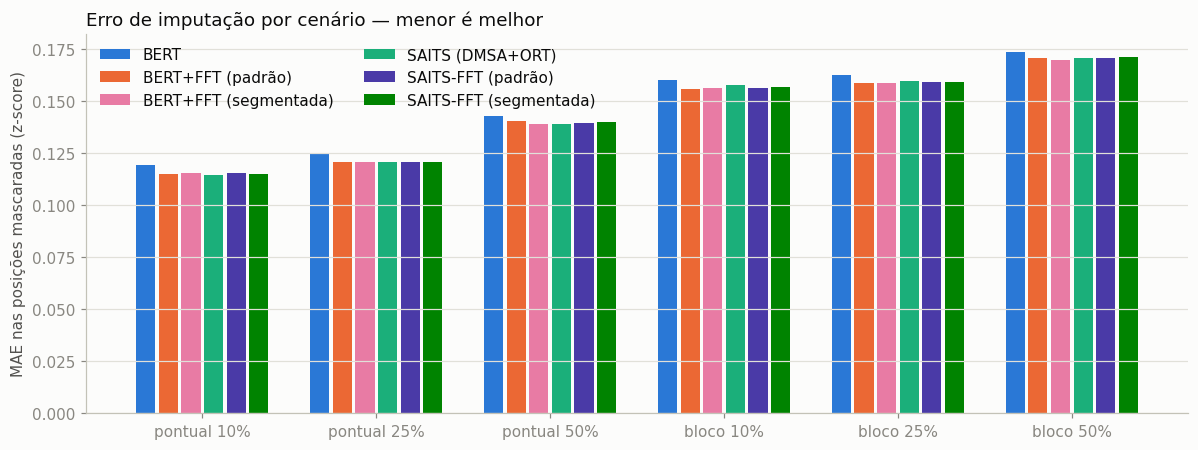

In [8]:
# barras agrupadas: 6 modelos (baselines ficam na tabela acima)
x = np.arange(len(nomes_cen))
larg = 0.13

fig, eixo = plt.subplots(figsize=(11, 4.2))
for k, nome in enumerate(ESPECS):
    v = tabela_mae.loc[nomes_cen, nome].to_numpy()
    eixo.bar(x + (k - 2.5) * larg, v, width=larg - 0.02,
             color=CORES_MODELOS[nome], label=nome)
eixo.set_xticks(x)
eixo.set_xticklabels(nomes_cen)
eixo.set_ylabel("MAE nas posições mascaradas (z-score)")
eixo.set_title("Erro de imputação por cenário — menor é melhor", loc="left")
eixo.legend(ncols=2, loc="upper left")
eixo.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

In [9]:
# resumo: média por tipo de cenário
resumo = []
for tipo in ("pontual", "bloco"):
    sel = [c for c in nomes_cen if c.startswith(tipo)]
    linha = {"tipo": tipo}
    for nome in ESPECS:
        linha[nome] = tabela_mae.loc[sel, nome].mean()
    resumo.append(linha)
resumo = pd.DataFrame(resumo).set_index("tipo")
resumo.round(4)

,BERT,BERT+FFT (padrão),BERT+FFT (segmentada),SAITS (DMSA+ORT),SAITS-FFT (padrão),SAITS-FFT (segmentada)
tipo,,,,,,
pontual,0.1288,0.1255,0.1251,0.1247,0.1252,0.1252
bloco,0.1656,0.1618,0.1616,0.1628,0.1621,0.1623


## Conclusões

**1. O orçamento de treino domina qualquer escolha arquitetural testada.** Com 300
épocas/paciência 30 (todos os modelos pararam entre 150 e 251 épocas), o MAE de todos
caiu ~8–12 % em relação ao orçamento de 40 épocas dos notebooks anteriores (ex.: BERT
no bloco 50 %: 0,188 → 0,174) — mais do que qualquer diferença entre arquiteturas
dentro do mesmo orçamento.

**2. Com treino longo, a FFT passou a ajudar o BERT — e muito.** BERT+FFT (padrão ou
segmentada) reduz o MAE do BERT em **−1,6 % a −3,6 %** em todos os 6 cenários, com
validação 0,0486/0,0488 vs 0,0504. É o oposto do regime de 40 épocas (notebook 04),
em que o token era inútil: o modelo precisa de épocas suficientes para aprender a
explorar o espectro. A FFT funciona aqui como um "atalho de otimização" que o BERT
puro não encontra sozinho nem com 150 épocas — mas que a família SAITS obtém por outro
caminho (ORT).

**3. A FFT segmentada (Welch) empata com a FFT padrão — com 3× menos dimensões.**
Δ% segmentada vs padrão na família BERT: entre +0,2 % e −0,9 %, com as únicas vantagens
claras nos cenários mais difíceis (pontual 50 %: −0,9 %; bloco 50 %: −0,6 %). Na
família SAITS o empate é ainda mais estreito (±0,3 %). Ou seja: a estratégia proposta
**preserva a informação espectral útil com 75 dims em vez de 255** (e ~11,5 k
parâmetros a menos), mas não a supera em acurácia — a hipótese de robustez a blocos
não se traduziu em ganho mensurável.

**4. A FFT continua não agregando ao SAITS.** SAITS-FFT (padrão ou segmentada) vs
SAITS: ±0,8 %, sem padrão consistente — confirma, agora em regime de treino longo, o
achado do notebook 04: DMSA+ORT já extrai do contexto o que o espectro forneceria.

**5. No teto do orçamento longo, cinco modelos empatam.** Média geral de MAE:
SAITS 0,1438, BERT+FFTs 0,1434, BERT+FFTp 0,1437, SAITS-FFTp 0,1437, SAITS-FFTs
0,1438 — só o BERT puro (0,1472) fica para trás. Por tipo: no pontual o melhor é o
SAITS (0,1247); no bloco, o BERT+FFT segmentada (0,1616). As diferenças entre os
cinco são < 0,5 % — sem repetição com múltiplas sementes, é um empate técnico.

**Leitura final.** Há dois caminhos equivalentes para fechar o gap do BERT: dar-lhe
informação espectral explícita (FFT no BERT) ou dar-lhe sinal de treino denso
(ORT+DMSA do SAITS) — os efeitos **não se somam** (SAITS+FFT ≈ SAITS). A contribuição
da FFT segmentada é de **eficiência de representação** (mesma acurácia, 29 % dos
coeficientes espectrais, menos parâmetros), não de acurácia. Ressalvas: semente única
(42); o refinamento 2P (notebook 05) não entrou neste orçamento — é o próximo passo
natural para tentar quebrar o empate.

**Artefatos** (nada anterior foi sobrescrito): `resultados/fft_segmentada/{6 modelos}/`,
`resultados/metricas_fft_seg.{csv,json}`, `resultados/comparacao_fft_seg.csv` e
`resultados/deltas_fft_seg.csv`.